In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [28]:
df=pd.read_csv('/content/HR_comma_sep.csv')

In [29]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [31]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'satisfaction_level'}>,
        <Axes: title={'center': 'last_evaluation'}>,
        <Axes: title={'center': 'number_project'}>],
       [<Axes: title={'center': 'average_montly_hours'}>,
        <Axes: title={'center': 'time_spend_company'}>,
        <Axes: title={'center': 'Work_accident'}>],
       [<Axes: title={'center': 'left'}>,
        <Axes: title={'center': 'promotion_last_5years'}>, <Axes: >]],
      dtype=object)

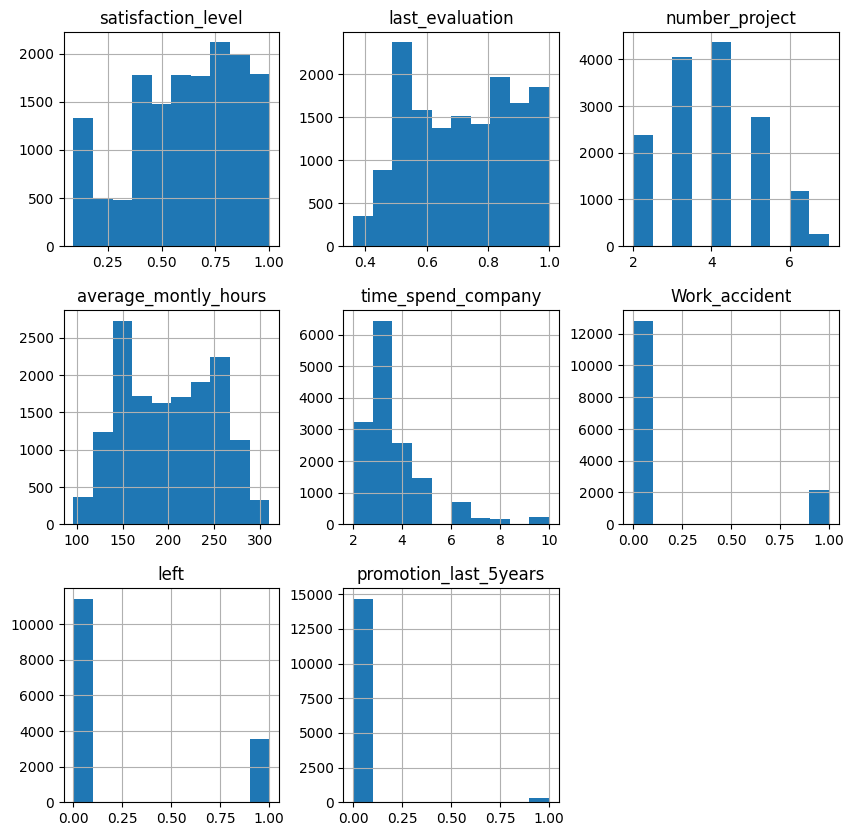

In [32]:
df.hist(figsize=(10,10))

<Axes: >

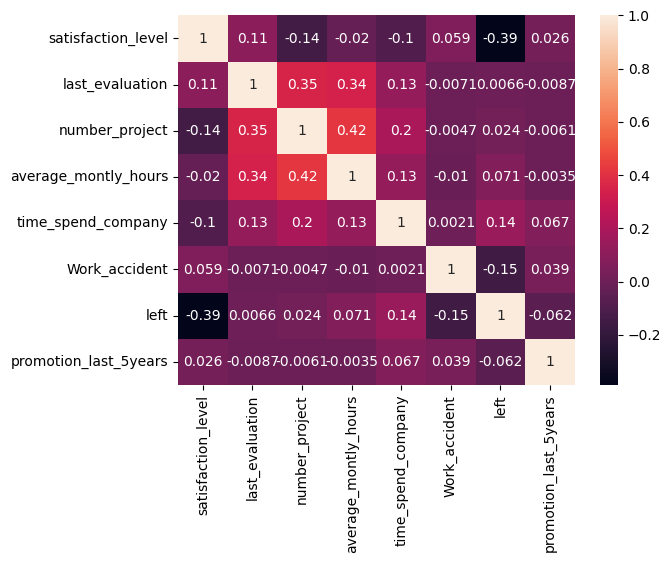

In [33]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [34]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [35]:
df.duplicated().sum()

np.int64(3008)

In [36]:
df.shape

(14999, 10)

In [37]:
df.drop_duplicates(inplace=True)

In [38]:
df.drop(columns=['last_evaluation', 'number_project'], inplace=True)

In [39]:
df_encoded=pd.get_dummies(df,columns=['salary','Department'])

In [40]:
df_encoded.head()

,satisfaction_level,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_high,salary_low,salary_medium,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,157,3,0,1,0,False,True,False,False,False,False,False,False,False,False,True,False,False
1,0.80,262,6,0,1,0,False,False,True,False,False,False,False,False,False,False,True,False,False
2,0.11,272,4,0,1,0,False,False,True,False,False,False,False,False,False,False,True,False,False
3,0.72,223,5,0,1,0,False,True,False,False,False,False,False,False,False,False,True,False,False
4,0.37,159,3,0,1,0,False,True,False,False,False,False,False,False,False,False,True,False,False


In [41]:
df_encoded.columns

Index(['satisfaction_level', 'average_montly_hours', 'time_spend_company',
       'Work_accident', 'left', 'promotion_last_5years', 'salary_high',
       'salary_low', 'salary_medium', 'Department_IT', 'Department_RandD',
       'Department_accounting', 'Department_hr', 'Department_management',
       'Department_marketing', 'Department_product_mng', 'Department_sales',
       'Department_support', 'Department_technical'],
      dtype='object')

In [42]:
columns=['salary_high','salary_low', 'salary_medium', 'Department_IT', 'Department_RandD',
       'Department_accounting', 'Department_hr', 'Department_management',
       'Department_marketing', 'Department_product_mng', 'Department_sales',
       'Department_support', 'Department_technical']

for i in columns:
  df_encoded[i]=df_encoded[i].astype(int)

In [43]:
df_encoded.head()

,satisfaction_level,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_high,salary_low,salary_medium,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,157,3,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0.80,262,6,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,272,4,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,223,5,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
4,0.37,159,3,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0


In [44]:
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
rf_model=RandomForestClassifier()
classifier_rf = RandomizedSearchCV(
    rf_model,
    {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    n_iter=10,
    cv=5,
    return_train_score=False,
    random_state=42
)
classifier_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42)

In [76]:
classifier_rf.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None}

In [116]:
rf_model=RandomForestClassifier(n_estimators= 100, max_depth=20, max_features='log2', min_samples_leaf=2,
                       min_samples_split=10)
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, max_features='log2', min_samples_leaf=2,
                       min_samples_split=10)

In [117]:
y_pred=rf_model.predict(X_test)

In [118]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model : {accuracy}")
print("Confusion Matrix : \n",confusion_matrix(y_test, y_pred))
print("Classification Report : \n",classification_report(y_test, y_pred))

Accuracy of the model : 0.9724847137298499
Confusion Matrix : 
 [[2959   36]
 [  63  540]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2995
           1       0.94      0.90      0.92       603

    accuracy                           0.97      3598
   macro avg       0.96      0.94      0.95      3598
weighted avg       0.97      0.97      0.97      3598



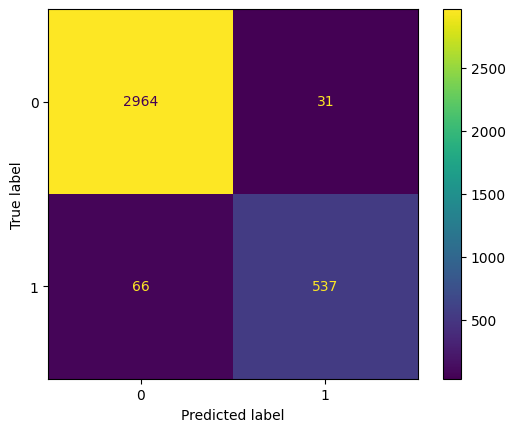

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.show()

In [122]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier()
classifier_xgb = RandomizedSearchCV(
    xgb_model,
    {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1],
    },
    n_iter=5,
    cv=5
)
classifier_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           learning_rate=None, max_bin=None,
                                           max_cat_threshold=None,
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=5,
                   param_distributions={'learning_rate': [0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300]})

In [126]:
classifier_xgb.best_params_

{'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}

In [127]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=7,
                          use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [128]:
y_pred_xgb=xgb_model.predict(X_test)

In [129]:
accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy of the model : {accuracy}")
print("Confusion Matrix : \n",confusion_matrix(y_test, y_pred_xgb))
print("Classification Report : \n",classification_report(y_test, y_pred_xgb))

Accuracy of the model : 0.9733185102834908
Confusion Matrix : 
 [[2953   42]
 [  54  549]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2995
           1       0.93      0.91      0.92       603

    accuracy                           0.97      3598
   macro avg       0.96      0.95      0.95      3598
weighted avg       0.97      0.97      0.97      3598

